## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?

    Because we am using the UTD-MHAD dataset (RGB video and IMU signals), the critical implication of "align before fuse" is to eliminate the inherent feature space barrier between high-dimensional visual semantics and low-dimensional physical dynamics, preventing the visual data from dominating model updates.

    Consequently, we will perform a **mid-to-late** phase-gated dynamic fusion, where a lightweight arbitrator dynamically routes the fusion weights based on the real-time biomechanical phase rather than using static early fusion.

    To ensure successful representation learning, we will explicitly avoid strict frame-to-point temporal alignment (such as DTW), which would destroy high-frequency IMU peaks or force alignment with motion-blurred frames. Instead, my alignment operates on three logical levels: macro time-window alignment (grouping modalities within the same absolute physical timeframe, e.g., 0.5s windows), latent space semantic alignment (using cross-modal contrastive loss to converge sequence-level representations), and biomechanical phase alignment (mapping the visual modality to the "preparation phase" and IMU to the "impact phase").

2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?

    To validate our approach, we will conduct two controlled experiments: first, comparing our macro-window alignment against a strict dynamic time warping (DTW) baseline (which we expect to fail by artificially warping high-frequency IMU peaks); second, comparing our dynamic Phase-Gated Mixture-of-Experts against static late fusion by injecting artificial motion blur during the impact phase to prove the gating mechanism prevents system collapse.

    we foresee three main challenges: hardware temporal drift between the Kinect and IMU sensors skewing my sliding windows; high-dimensional visual features dominating the shared latent space despite contrastive loss; and phase transition ambiguity in actions lacking sharp ballistic impacts, which could cause my arbitrator network to oscillate unstably rather than executing a clean modality switch.

3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?

    The Platonic Representation Hypothesis implies our Vision and IMU encoders could theoretically converge to a shared, universal representation of an action as model scale increases. However, We do not believe this alignment will emerge automatically on our data. Due to extreme temporal heterogeneity, Vision and IMU observe fundamentally different physical phases (semantic preparation vs. high-frequency impact). Because vision suffers motion blur exactly when IMU acceleration peaks, they lack the concurrent, high-quality overlapping signals required for natural statistical convergence. Therefore, explicit biomechanical phase alignment remains structurally necessary regardless of model scale.

4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.

    Counter-arguments to the Platonic Representation Hypothesis primarily center on the inherent physical and algorithmic limitations of statistical scaling. The fundamental "modality gap" dictates that different sensors capture mutually exclusive physical dimensions; for instance, scaling alone cannot force an IMU to learn spatial semantics or a camera to learn physical force. Furthermore, latent spaces are subject to task-specific warping, meaning models optimize their representations for specific loss functions rather than naturally collapsing into a single universal reality. Finally, the embodiment bottleneck suggests that purely statistical models only map human-curated dataset biases. Without direct physical interaction and causal grounding in the real world, models lack the necessary physical constraints to form a true, universal Platonic representation regardless of their scale.

5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?

    To validate the emergence of alignment in our task, we propose conducting a cross-modal representation similarity analysis and a zero-shot retrieval test. First, we would compute the Centered Kernel Alignment (CKA) between the latent spaces of our Vision and IMU encoders across different training scales to quantify if their topological structures are naturally converging. Second, we would perform cross-modal instance retrieval, using a frozen visual sequence of a specific action (like a punch) to query the corresponding IMU sequence from the dataset. High retrieval accuracy and increasing CKA scores across epochs would empirically prove that these two highly heterogeneous modalities have successfully aligned onto the same semantic physical event in the shared latent space.

6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

    The main downside is "modality collapse," where Vision and IMU over-homogenize and lose their unique, complementary physical features.

    To validate this risk is absent, we will conduct a phase-specific modality dropout experiment. Masking the IMU specifically during the impact phase must cause a severe accuracy drop; if performance remains unaffected, it proves the modalities have redundantly over-aligned.

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [ ]:
# Common PyTorch operations

# Adding
mat_C = torch.add(mat_A, mat_B.T)

# Transpose
mat_A_transpose = torch.transpose(mat_A, 0, 1)

# Matrix multiplication
mat_mult  = torch.matmul(mat_A, mat_B)

# Element-wise multiplication
mat_mult_elm = torch.mul(mat_A_transpose, mat_B)

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = torch.mean(mat_A)


# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.3900, 0.3532, 0.3082],
        [0.2683, 0.1659, 0.2595],
        [0.4906, 0.2539, 0.5051]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij -> ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.sum(A)
sum_column = torch.sum(A, dim=0)

# Diagonal of A
diag = torch.einsum('ii->i', A[:2, :2])

# Outer Product of A and B
outer = torch.einsum('ij, kl -> ijkl', A, B)

In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert torch.isclose(torch.tensor(float(ans)), torch.tensor(float(expected)), atol=1e-5)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected


def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert torch.isclose(torch.tensor(float(ans)), torch.tensor(float(expected)), atol=1e-5)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert all(torch.isclose(torch.tensor(a), torch.tensor(e), atol=1e-5)
               for a, e in zip(to_list(ans), expected))

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert torch.isclose(torch.tensor(float(ans)), torch.tensor(float(expected)), atol=1e-5)


check_dot_product(d_prod, a.flatten(), b.flatten())
check_transpose(transpose, b)
check_sum_element(sum_element, A)
check_sum_column(sum_column, A)
check_diagonal(diag, A[:2, :2])
print("All tests passed!")

All tests passed!


# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

Cloning into 'MultiBench'...
remote: Enumerating objects: 6943, done.
remote: Counting objects: 100% (402/402), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 6943 (delta 363), reused 341 (delta 341), pack-reused 6541 (from 1)
Receiving objects: 100% (6943/6943), 51.03 MiB | 13.50 MiB/s, done.
Resolving deltas: 100% (4281/4281), done.
/content/MultiBench/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

In [ ]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=467f3af8-ab8a-4ab6-9804-5f7a214f04cd
To: /content/MultiBench/avmnist.tar.gz
100% 1.60G/1.60G [00:21<00:00, 75.1MB/s]
avmnist/
avmnist/test_labels.npy
avmnist/image/
avmnist/image/train_data.npy
avmnist/image/test_data.npy
avmnist/audio/
avmnist/audio/train_data.npy
avmnist/audio/test_data.npy
avmnist/train_labels.npy
avmnist/avmnist_temp/
avmnist/avmnist_temp/train_labels.npy
avmnist/avmnist_temp/image/
avmnist/avmnist_temp/image/test_data.npy
avmnist/avmnist_temp/image/train_data.npy
avmnist/avmnist_temp/test_labels.npy


In [ ]:
import importlib.util, sys

sys.path.insert(0, '/content/MultiBench')

spec = importlib.util.spec_from_file_location(
    "get_data",
    "/content/MultiBench/datasets/avmnist/get_data.py"
)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

data_dir = '/content/MultiBench/avmnist'
traindata, validdata, testdata = mod.get_dataloader(data_dir, batch_size=256)
print("Data loaded successfully!")

Data loaded successfully!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [ ]:
import torch
import torch.nn as nn
import sys

sys.path.insert(0, '/content/MultiBench')
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test
import torch.nn.functional as F

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [ ]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [ ]:
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

In [ ]:
import torch.nn.functional as F

class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.3):
        super(ImageModel, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 28->14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 14->7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten()                                  # 128*7*7=6272
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


class AudioModel(nn.Module):
    def __init__(self, dropout_probability=0.3):
        super(AudioModel, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 112->56
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                                         # 56->28

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 28->14
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),             # 14->14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Flatten()                                             # 64*14*14=12544
        )

        self.fc = nn.Sequential(
            nn.Linear(12544, 256),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Audio:

In [ ]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 2.1087 | Valid Acc: 37.80%
Epoch 1: Train Loss: 2.0234 | Valid Acc: 39.46%
Epoch 2: Train Loss: 2.0003 | Valid Acc: 40.66%
Epoch 3: Train Loss: 1.9830 | Valid Acc: 41.26%
Epoch 4: Train Loss: 1.9683 | Valid Acc: 41.28%

--- Final Evaluation Complete ---
Final Test Loss: 2.0210 | Test Accuracy: 41.27%


In [ ]:
audio_model = AudioModel(dropout_probability=0.3)
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1, epochs=15, lr=3e-4)

Epoch 0: Train Loss: 2.0465 | Valid Acc: 41.62%
Epoch 1: Train Loss: 1.9657 | Valid Acc: 42.02%
Epoch 2: Train Loss: 1.9419 | Valid Acc: 42.18%
Epoch 3: Train Loss: 1.9302 | Valid Acc: 42.22%
Epoch 4: Train Loss: 1.9199 | Valid Acc: 42.12%
Epoch 5: Train Loss: 1.9161 | Valid Acc: 42.20%
Epoch 6: Train Loss: 1.9106 | Valid Acc: 42.18%
Epoch 7: Train Loss: 1.9043 | Valid Acc: 42.18%
Epoch 8: Train Loss: 1.9006 | Valid Acc: 42.18%
Epoch 9: Train Loss: 1.8980 | Valid Acc: 42.22%
Epoch 10: Train Loss: 1.8960 | Valid Acc: 42.18%
Epoch 11: Train Loss: 1.8948 | Valid Acc: 42.20%
Epoch 12: Train Loss: 1.8916 | Valid Acc: 42.16%
Epoch 13: Train Loss: 1.8937 | Valid Acc: 42.20%
Epoch 14: Train Loss: 1.8900 | Valid Acc: 42.14%

--- Final Evaluation Complete ---
Final Test Loss: 2.0065 | Test Accuracy: 41.22%


# Image:

In [ ]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

Epoch 0: Train Loss: 1.1118 | Valid Acc: 65.40%
Epoch 1: Train Loss: 0.9424 | Valid Acc: 68.10%
Epoch 2: Train Loss: 0.9233 | Valid Acc: 67.96%
Epoch 3: Train Loss: 0.9139 | Valid Acc: 68.74%
Epoch 4: Train Loss: 0.9083 | Valid Acc: 68.92%

--- Final Evaluation Complete ---
Final Test Loss: 0.8935 | Test Accuracy: 64.63%


In [ ]:
image_model = ImageModel(dropout_prob=0.3)
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0, epochs=15, lr=3e-4)


Epoch 0: Train Loss: 0.9852 | Valid Acc: 67.62%
Epoch 1: Train Loss: 0.9072 | Valid Acc: 68.80%
Epoch 2: Train Loss: 0.8941 | Valid Acc: 69.34%
Epoch 3: Train Loss: 0.8832 | Valid Acc: 69.34%
Epoch 4: Train Loss: 0.8769 | Valid Acc: 69.24%
Epoch 5: Train Loss: 0.8767 | Valid Acc: 69.48%
Epoch 6: Train Loss: 0.8748 | Valid Acc: 69.58%
Epoch 7: Train Loss: 0.8695 | Valid Acc: 69.28%
Epoch 8: Train Loss: 0.8673 | Valid Acc: 69.22%
Epoch 9: Train Loss: 0.8652 | Valid Acc: 69.12%
Epoch 10: Train Loss: 0.8644 | Valid Acc: 69.06%
Epoch 11: Train Loss: 0.8629 | Valid Acc: 69.18%
Epoch 12: Train Loss: 0.8627 | Valid Acc: 69.72%
Epoch 13: Train Loss: 0.8613 | Valid Acc: 68.70%
Epoch 14: Train Loss: 0.8599 | Valid Acc: 69.10%

--- Final Evaluation Complete ---
Final Test Loss: 0.8703 | Test Accuracy: 65.22%


In [ ]:
# 检查
print(image_model)


ImageModel(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Flatten(start_dim=1, end_dim=-1)
  )
  (fc): Sequential(
    (0): Linear(in_features=6272, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.

    Image Model:
    - Best Test Accuracy: 65.22%
    - Best Hyperparameters: epochs=15, lr=3e-4, dropout=0.3,
      added BatchNorm2d after each conv layer, 3 conv layers

    Audio Model:
    - Best Test Accuracy: 41.27%
    - Best Hyperparameters: epochs=5, lr=1e-3, dropout=0.2 (baseline)
      Additional epochs and BatchNorm did not improve performance,
      suggesting the audio spectrogram features are harder to learn
      with this architecture.


2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

    **Comparison of Modality Performances:**
    The Image model achieved a best test accuracy of 65.22%, while the Audio model only reached 41.27%. This is a significant gap of approximately 24%, showing that the image modality is substantially easier to classify than the audio modality on the AV-MNIST dataset.
    
    The performance gap suggests that the audio spectrograms contain less discriminative information than the images for digit classification. Images of handwritten digits have clear spatial structure that CNNs can easily learn, while audio spectrograms of spoken digits are more variable across speakers, accents, and speaking speeds, making them inherently harder to classify.
    What could be done to improve Audio performance?

    1)Better architecture: Replace the CNN with a model better suited for audio, such as a RNN or Transformer, which can capture temporal patterns in speech more effectively.
    
    2)Data augmentation: Apply techniques like time-stretching, pitch-shifting, or adding noise to increase the diversity of training data.

    3)Better preprocessing: Instead of raw spectrograms, use MFCCs (Mel-Frequency Cepstral Coefficients), which are more commonly used for speech recognition tasks.

    4)Deeper network: Add more convolutional layers to extract richer features from the audio spectrograms.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
!pip install sympy==1.13.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 81.9 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0


In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(output_dim=64), AudioEncoder(output_dim=64)]

# Use the concat fusion as the fusion of choice
fusion = Concat()

# Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = MLP(128, 256, 10)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0 train loss: tensor(0.8953, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7303, device='cuda:0') acc: 0.7324
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(0.7548, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7367, device='cuda:0') acc: 0.7236


...

Epoch 3 train loss: tensor(0.6858, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7279, device='cuda:0') acc: 0.731


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(0.6502, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7484, device='cuda:0') acc: 0.7192
Training Time: 87.72991251945496
Training Peak Mem: 9913.21484375
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.7081
Inference Time: 2.891281843185425
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?

    this suggests the model is stuck in a local minimum or the learning rate is too high/too low.
    possible fixes includes:
    1) lower learning rate, the model may be overshooting the minimum
    2) use a learning rate schedule, gradually decrease learning rate during training
    3) add BatchNrom, stabilizes training and helps gradients flow
    4) change optimizer, try Adam, instead of SGD or AdamW
    5) check for vanishing gradients, use different activation function or add more skip connections.
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?

    multiplicative interactions(MI): models interactions between modalities by multiplying their representations, capturing more complex relationships than simple concatenation
    low-rank multimodal fusion(LMF): decomposes the fusion tensor into low-rank factors, more efficient for high-dimensional inputs
    transfermer-based fusion: uses attention mechanisms to dynamically weight each modality's contribution

    compared to early fusion, these late fusion methods generally lead to improvements because each modality is first processed independently to extract meaningful features before being combined, rather than merging raw inputs that may have very different scales and structures

3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

    early fusion combines raw inputs from all modalities at the very beginning before any processing, which is simple to implement but struggles because different modalities like images and audio have very different scales and formats. Late fusion instead processes each modality through its own specialized encoder first, then combines the learned representations, allowing each encoder to focus on modality-specific features and generally achieving better performance. The tradeoff is that late fusion is more complex to design and may miss low-level cross-modal interactions, while early fusion is simpler but less effective when modalities are fundamentally different in nature.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

In [ ]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable
import scipy.io
import numpy as np
import cv2
import os
from torch.utils.data import Dataset, DataLoader
import time
import wandb


## Loading Dataset

In [ ]:
# load Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class UTDDataset(Dataset):
    def __init__(self, base_path, num_frames=10, img_size=64):
        self.samples = []
        self.num_frames = num_frames
        self.img_size = img_size

        rgb_dirs = [f'{base_path}/RGB-part{i}' for i in range(1, 5)]
        inertial_dir = f'{base_path}/Inertial'

        for fname in os.listdir(inertial_dir):
            if not fname.endswith('_inertial.mat'):
                continue
            base = fname.replace('_inertial.mat', '')
            action = int(base.split('_')[0][1:])
            label = action - 1

            rgb_file = None
            for rgb_dir in rgb_dirs:
                candidate = f'{rgb_dir}/{base}_color.avi'
                if os.path.exists(candidate):
                    rgb_file = candidate
                    break

            if rgb_file is None:
                continue

            inertial_file = f'{inertial_dir}/{fname}'
            self.samples.append((rgb_file, inertial_file, label))

    def __len__(self):
        return len(self.samples)

    def load_video(self, path):
        cap = cv2.VideoCapture(path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.resize(frame, (self.img_size, self.img_size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frames.append(frame)
        cap.release()

        frames = np.array(frames)
        indices = np.linspace(0, len(frames)-1, self.num_frames, dtype=int)
        frames = frames[indices]
        return frames.astype(np.float32) / 255.0

    def __getitem__(self, idx):
        rgb_file, inertial_file, label = self.samples[idx]

        # Load RGB
        video = self.load_video(rgb_file)
        video = torch.tensor(video).unsqueeze(1)  # (num_frames, 1, 64, 64)

        # Load IMU and fix length to 160
        mat = scipy.io.loadmat(inertial_file)
        imu = mat['d_iner'].astype(np.float32)

        target_len = 160
        if imu.shape[0] >= target_len:
            imu = imu[:target_len, :]
        else:
            pad = np.zeros((target_len - imu.shape[0], 6), dtype=np.float32)
            imu = np.concatenate([imu, pad], axis=0)

        imu = torch.tensor(imu)  # (160, 6)

        return video, imu, torch.tensor(label, dtype=torch.long)


# Recreate dataset and dataloaders
base_path = '/content/drive/MyDrive/utd_mhad'
dataset = UTDDataset(base_path, num_frames=10, img_size=64)

total = len(dataset)
train_size = int(0.7 * total)
valid_size = int(0.15 * total)
test_size = total - train_size - valid_size

train_set, valid_set, test_set = torch.utils.data.random_split(
    dataset, [train_size, valid_size, test_size]
)

traindata = DataLoader(train_set, batch_size=16, shuffle=True)
validdata = DataLoader(valid_set, batch_size=16, shuffle=False)
testdata  = DataLoader(test_set,  batch_size=16, shuffle=False)

print(f"Train: {len(train_set)}, Valid: {len(valid_set)}, Test: {len(test_set)}")

Train: 602, Valid: 129, Test: 130


## Video Encoder

In [ ]:
class VideoEncoder(nn.Module):
    def __init__(self, num_frames=10, output_dim=64):
        super().__init__()
        # CNN to extract features from each frame
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1,64,64) -> (32,64,64)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (32,32,32)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # -> (64,32,32)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (64,16,16)
            nn.Flatten(),                                 # -> 64*16*16=16384
            nn.Linear(64*16*16, output_dim)
        )
        self.num_frames = num_frames

    def forward(self, x):
        # x: (batch, num_frames, 1, 64, 64)
        batch = x.shape[0]
        # Merge frames into batch dimension for parallel processing
        x = x.view(batch * self.num_frames, 1, 64, 64)
        x = self.cnn(x)                          # (batch*frames, output_dim)
        x = x.view(batch, self.num_frames, -1)   # (batch, frames, output_dim)
        x = x.mean(dim=1)                        # Average pooling over frames
        return x

## IMU Encoder

In [ ]:
class IMUEncoder(nn.Module):
    def __init__(self, input_dim=6, output_dim=64):
        super().__init__()
        # GRU to capture temporal patterns in IMU signal
        self.gru = nn.GRU(input_dim, 128, num_layers=2,
                          batch_first=True, dropout=0.3)
        self.fc = nn.Linear(128, output_dim)

    def forward(self, x):
        # x: (batch, 160, 6)
        out, _ = self.gru(x)      # (batch, 160, 128)
        out = out[:, -1, :]       # Take last hidden state (batch, 128)
        return self.fc(out)       # (batch, output_dim)

## Train Model

In [ ]:
def count_parameters(model):
    """Count total trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    return 0

def train_model_wandb(model, traindata, validdata, model_name, epochs=10, lr=1e-3):
    # Initialize wandb run
    wandb.init(
        project="utd-mhad-fusion",
        name=model_name,
        config={
            "model": model_name,
            "epochs": epochs,
            "lr": lr,
            "optimizer": "AdamW",
            "weight_decay": 1e-3,
            "num_params": count_parameters(model)
        }
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    # Log model parameter count
    num_params = count_parameters(model)
    print(f"{model_name} - Parameters: {num_params:,}")
    wandb.log({"num_parameters": num_params})

    best_valid_acc = 0
    start_time = time.time()
    convergence_epoch = 0

    for epoch in range(epochs):
        epoch_start = time.time()

        # Training phase
        model.train()
        train_loss = 0
        for video, imu, labels in traindata:
            video  = video.to(device).float()
            imu    = imu.to(device).float()
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model([video, imu])
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation phase
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for video, imu, labels in validdata:
                video  = video.to(device).float()
                imu    = imu.to(device).float()
                labels = labels.to(device)

                outputs = model([video, imu])
                _, predicted = torch.max(outputs, 1)
                total   += labels.size(0)
                correct += (predicted == labels).sum().item()

        valid_acc = 100 * correct / total
        avg_train_loss = train_loss / len(traindata)
        epoch_time = time.time() - epoch_start
        memory_mb = get_memory_usage()

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            convergence_epoch = epoch
            torch.save(model.state_dict(), f'best_{model_name}.pt')

        # Log to wandb
        wandb.log({
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "valid_acc": valid_acc,
            "epoch_time_sec": epoch_time,
            "memory_mb": memory_mb,
        })

        print(f"Epoch {epoch}: Loss={avg_train_loss:.4f} | Valid Acc={valid_acc:.2f}% | Memory={memory_mb:.1f}MB")

    total_time = time.time() - start_time

    # Log final summary
    wandb.log({
        "best_valid_acc": best_valid_acc,
        "convergence_epoch": convergence_epoch,
        "total_time_sec": total_time,
    })

    print(f"\nBest Valid Acc: {best_valid_acc:.2f}% at Epoch {convergence_epoch}")
    print(f"Total Training Time: {total_time:.1f}s")

    wandb.finish()
    return best_valid_acc


In [ ]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hang1006 (hang1006-harvard-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Early Fusion

In [ ]:
class EarlyFusion(nn.Module):
  def __init__(self):
    super(EarlyFusion, self).__init__()

  def forward(self, x):
    return torch.einsum('bi,bj->bij', x[0], x[1])

class EarlyFusionModel(nn.Module):
    def __init__(self, num_classes=27, output_dim=64):
        super().__init__()
        self.video_encoder = VideoEncoder(output_dim=output_dim)
        self.imu_encoder = IMUEncoder(output_dim=output_dim)
        self.fusion = EarlyFusion()
        self.head = nn.Sequential(
            nn.Linear(output_dim * output_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        video_feat = self.video_encoder(x[0])
        imu_feat = self.imu_encoder(x[1])
        fused = self.fusion([video_feat, imu_feat])
        fused = fused.view(fused.shape[0], -1)
        return self.head(fused)



# (5 Points) Late Fusion

In [ ]:
# ======= 2. Late Fusion =======
class LateFusion(nn.Module):
    def __init__(self):
        super(LateFusion, self).__init__()
    def forward(self, x):
        # Concatenate encoded features from each modality
        return torch.cat([x[0], x[1]], dim=-1)

class LateFusionModel(nn.Module):
    def __init__(self, num_classes=27, output_dim=64):
        super().__init__()
        self.video_encoder = VideoEncoder(output_dim=output_dim)
        self.imu_encoder = IMUEncoder(output_dim=output_dim)
        self.fusion = LateFusion()
        self.head = nn.Sequential(
            nn.Linear(output_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        video_feat = self.video_encoder(x[0])
        imu_feat = self.imu_encoder(x[1])
        fused = self.fusion([video_feat, imu_feat])
        return self.head(fused)


# (5 points) Tensor Fusion

In [ ]:
# ======= 3. Tensor Fusion =======
class TensorFusion(nn.Module):
    def __init__(self):
        super(TensorFusion, self).__init__()
    def forward(self, x):
        # Append bias term (1) to each modality
        batch = x[0].shape[0]
        ones = torch.ones(batch, 1).to(x[0].device)
        v = torch.cat([x[0], ones], dim=1)  # (batch, 65)
        i = torch.cat([x[1], ones], dim=1)  # (batch, 65)
        # Outer product via einsum
        return torch.einsum('bi,bj->bij', v, i)  # (batch, 65, 65)

class TensorFusionModel(nn.Module):
    def __init__(self, num_classes=27, output_dim=64):
        super().__init__()
        self.video_encoder = VideoEncoder(output_dim=output_dim)
        self.imu_encoder = IMUEncoder(output_dim=output_dim)
        self.fusion = TensorFusion()
        fused_dim = (output_dim + 1) * (output_dim + 1)
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        video_feat = self.video_encoder(x[0])
        imu_feat = self.imu_encoder(x[1])
        fused = self.fusion([video_feat, imu_feat])
        fused = fused.view(fused.shape[0], -1)
        return self.head(fused)


# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [ ]:
# ======= 4. LMF Fusion =======
class LMFFusion(nn.Module):
    def __init__(self, video_dim=64, imu_dim=64, rank=4, num_classes=27):
        super(LMFFusion, self).__init__()
        self.rank = rank
        # Low-rank factors for each modality
        self.video_factor = nn.Parameter(torch.randn(rank, video_dim + 1))
        self.imu_factor = nn.Parameter(torch.randn(rank, imu_dim + 1))
        self.fusion_weights = nn.Parameter(torch.randn(rank, num_classes))

    def forward(self, x):
        batch = x[0].shape[0]
        ones = torch.ones(batch, 1).to(x[0].device)
        video_feat = torch.cat([x[0], ones], dim=1)  # (batch, 65)
        imu_feat = torch.cat([x[1], ones], dim=1)    # (batch, 65)

        # Project each modality onto rank space using einsum
        video_scores = torch.einsum('ri,bi->br', self.video_factor, video_feat)
        imu_scores = torch.einsum('ri,bi->br', self.imu_factor, imu_feat)

        # Element-wise product across rank dimension
        fused = video_scores * imu_scores  # (batch, rank)

        # Project to output classes
        return torch.einsum('br,rc->bc', fused, self.fusion_weights)

class LMFFusionModel(nn.Module):
    def __init__(self, num_classes=27, output_dim=64, rank=4):
        super().__init__()
        self.video_encoder = VideoEncoder(output_dim=output_dim)
        self.imu_encoder = IMUEncoder(output_dim=output_dim)
        self.fusion = LMFFusion(video_dim=output_dim, imu_dim=output_dim,
                                rank=rank, num_classes=num_classes)
        self.head = nn.Sequential(
            nn.Linear(num_classes, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        video_feat = self.video_encoder(x[0])
        imu_feat = self.imu_encoder(x[1])
        fused = self.fusion([video_feat, imu_feat])
        return self.head(fused)


## Train and visualize

In [ ]:
# Run all four fusion models
print("=== Early Fusion ===")
model_ef = EarlyFusionModel(num_classes=27, output_dim=64)
train_model_wandb(model_ef, traindata, validdata, "EarlyFusion", epochs=10, lr=1e-3)

print("\n=== Late Fusion ===")
model_lf = LateFusionModel(num_classes=27, output_dim=64)
train_model_wandb(model_lf, traindata, validdata, "LateFusion", epochs=10, lr=1e-3)

print("\n=== Tensor Fusion ===")
model_tf = TensorFusionModel(num_classes=27, output_dim=64)
train_model_wandb(model_tf, traindata, validdata, "TensorFusion", epochs=10, lr=1e-3)

print("\n=== LMF Fusion ===")
model_lmf = LMFFusionModel(num_classes=27, output_dim=64, rank=4)
train_model_wandb(model_lmf, traindata, validdata, "LMFFusion", epochs=10, lr=1e-3)


=== Early Fusion ===


num_parameters,▁
num_parameters,2282971


EarlyFusion - Parameters: 2,282,971
Epoch 0: Loss=3.6569 | Valid Acc=6.98% | Memory=89.1MB
Epoch 1: Loss=3.1166 | Valid Acc=13.18% | Memory=89.1MB
Epoch 2: Loss=2.9797 | Valid Acc=13.18% | Memory=89.1MB
Epoch 3: Loss=2.8073 | Valid Acc=16.28% | Memory=89.1MB
Epoch 4: Loss=2.8776 | Valid Acc=15.50% | Memory=89.1MB
Epoch 5: Loss=2.7659 | Valid Acc=13.18% | Memory=89.1MB
Epoch 6: Loss=2.4788 | Valid Acc=23.26% | Memory=89.1MB
Epoch 7: Loss=2.2691 | Valid Acc=26.36% | Memory=89.1MB
Epoch 8: Loss=2.0689 | Valid Acc=20.16% | Memory=89.1MB
Epoch 9: Loss=1.9125 | Valid Acc=27.13% | Memory=89.1MB

Best Valid Acc: 27.13% at Epoch 9
Total Training Time: 1205.4s


best_valid_acc,▁
convergence_epoch,▁
epoch,▁▂▃▃▄▅▆▆▇█
epoch_time_sec,█▁▁▁▁▁▁▁▁▁
memory_mb,▁▁▁▁▁▁▁▁▁▁
num_parameters,▁
total_time_sec,▁
train_loss,█▆▅▅▅▄▃▂▂▁
valid_acc,▁▃▃▄▄▃▇█▆█
best_valid_acc,27.13178
convergence_epoch,9



=== Late Fusion ===


...

best_valid_acc,▁
convergence_epoch,▁
epoch,▁▂▃▃▄▅▆▆▇█
epoch_time_sec,▁▅▆▇▃▅▆█▃▅
memory_mb,▁▁▁▁▁▁▁▁▁▁
num_parameters,▁
total_time_sec,▁
train_loss,█▆▅▅▄▄▃▂▂▁
valid_acc,▂▁▃▂▅▄▆▇██
best_valid_acc,27.13178
convergence_epoch,8



=== LMF Fusion ===


LMFFusion - Parameters: 1,234,895
Epoch 0: Loss=81.3048 | Valid Acc=0.78% | Memory=119.5MB
Epoch 1: Loss=14.0638 | Valid Acc=3.10% | Memory=119.5MB
Epoch 2: Loss=6.1515 | Valid Acc=6.98% | Memory=119.5MB
Epoch 3: Loss=5.3013 | Valid Acc=5.43% | Memory=119.5MB
Epoch 4: Loss=4.6712 | Valid Acc=2.33% | Memory=119.5MB
Epoch 5: Loss=4.1339 | Valid Acc=0.00% | Memory=119.5MB
Epoch 6: Loss=3.9245 | Valid Acc=3.10% | Memory=119.5MB
Epoch 7: Loss=3.8061 | Valid Acc=2.33% | Memory=119.5MB
Epoch 8: Loss=3.5104 | Valid Acc=7.75% | Memory=119.5MB
Epoch 9: Loss=3.5107 | Valid Acc=4.65% | Memory=119.5MB

Best Valid Acc: 7.75% at Epoch 8
Total Training Time: 567.1s


best_valid_acc,▁
convergence_epoch,▁
epoch,▁▂▃▃▄▅▆▆▇█
epoch_time_sec,▇▅▄▄▁█▆▄▁▆
memory_mb,▁▁▁▁▁▁▁▁▁▁
num_parameters,▁
total_time_sec,▁
train_loss,█▂▁▁▁▁▁▁▁▁
valid_acc,▂▄▇▆▃▁▄▃█▅
best_valid_acc,7.75194
convergence_epoch,8


7.751937984496124

1. (10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

## Answer
Unimodal models are simpler, faster to train, and require less memory since they only process one source of data. In our experiments, the unimodal Image model achieved 65.22% accuracy and the IMU model achieved 41.27%. However, each unimodal model is limited to the information available in a single modality and cannot capture cross-modal relationships.
    
Multimodal models, on the other hand, combine information from multiple modalities and can potentially learn richer representations. However, our multimodal fusion models only achieved around 27-33% validation accuracy, which is actually lower than the unimodal image model. This is likely because the dataset is small (861 samples) and the models did not have enough data to learn effective cross-modal representations within only 10 epochs.

Among the four fusion techniques, Late Fusion performed best at 33%, likely because each modality is encoded independently before fusion, allowing each encoder to specialize. Early Fusion and Tensor Fusion achieved similar accuracy 27% but Tensor Fusion used significantly more memory. LMF performed the worst at only 8%, possibly because the low-rank approximation is too restrictive for this dataset. In terms of efficiency, Late Fusion and LMF were the fastest to train (580s) while Early Fusion took twice as long (~1200s) due to the large 4096-dimensional fused representation requiring more computation in the classification head.

In [ ]:
# Display wandb plots directly in Colab
%wandb hang1006-harvard-university/utd-mhad-fusion

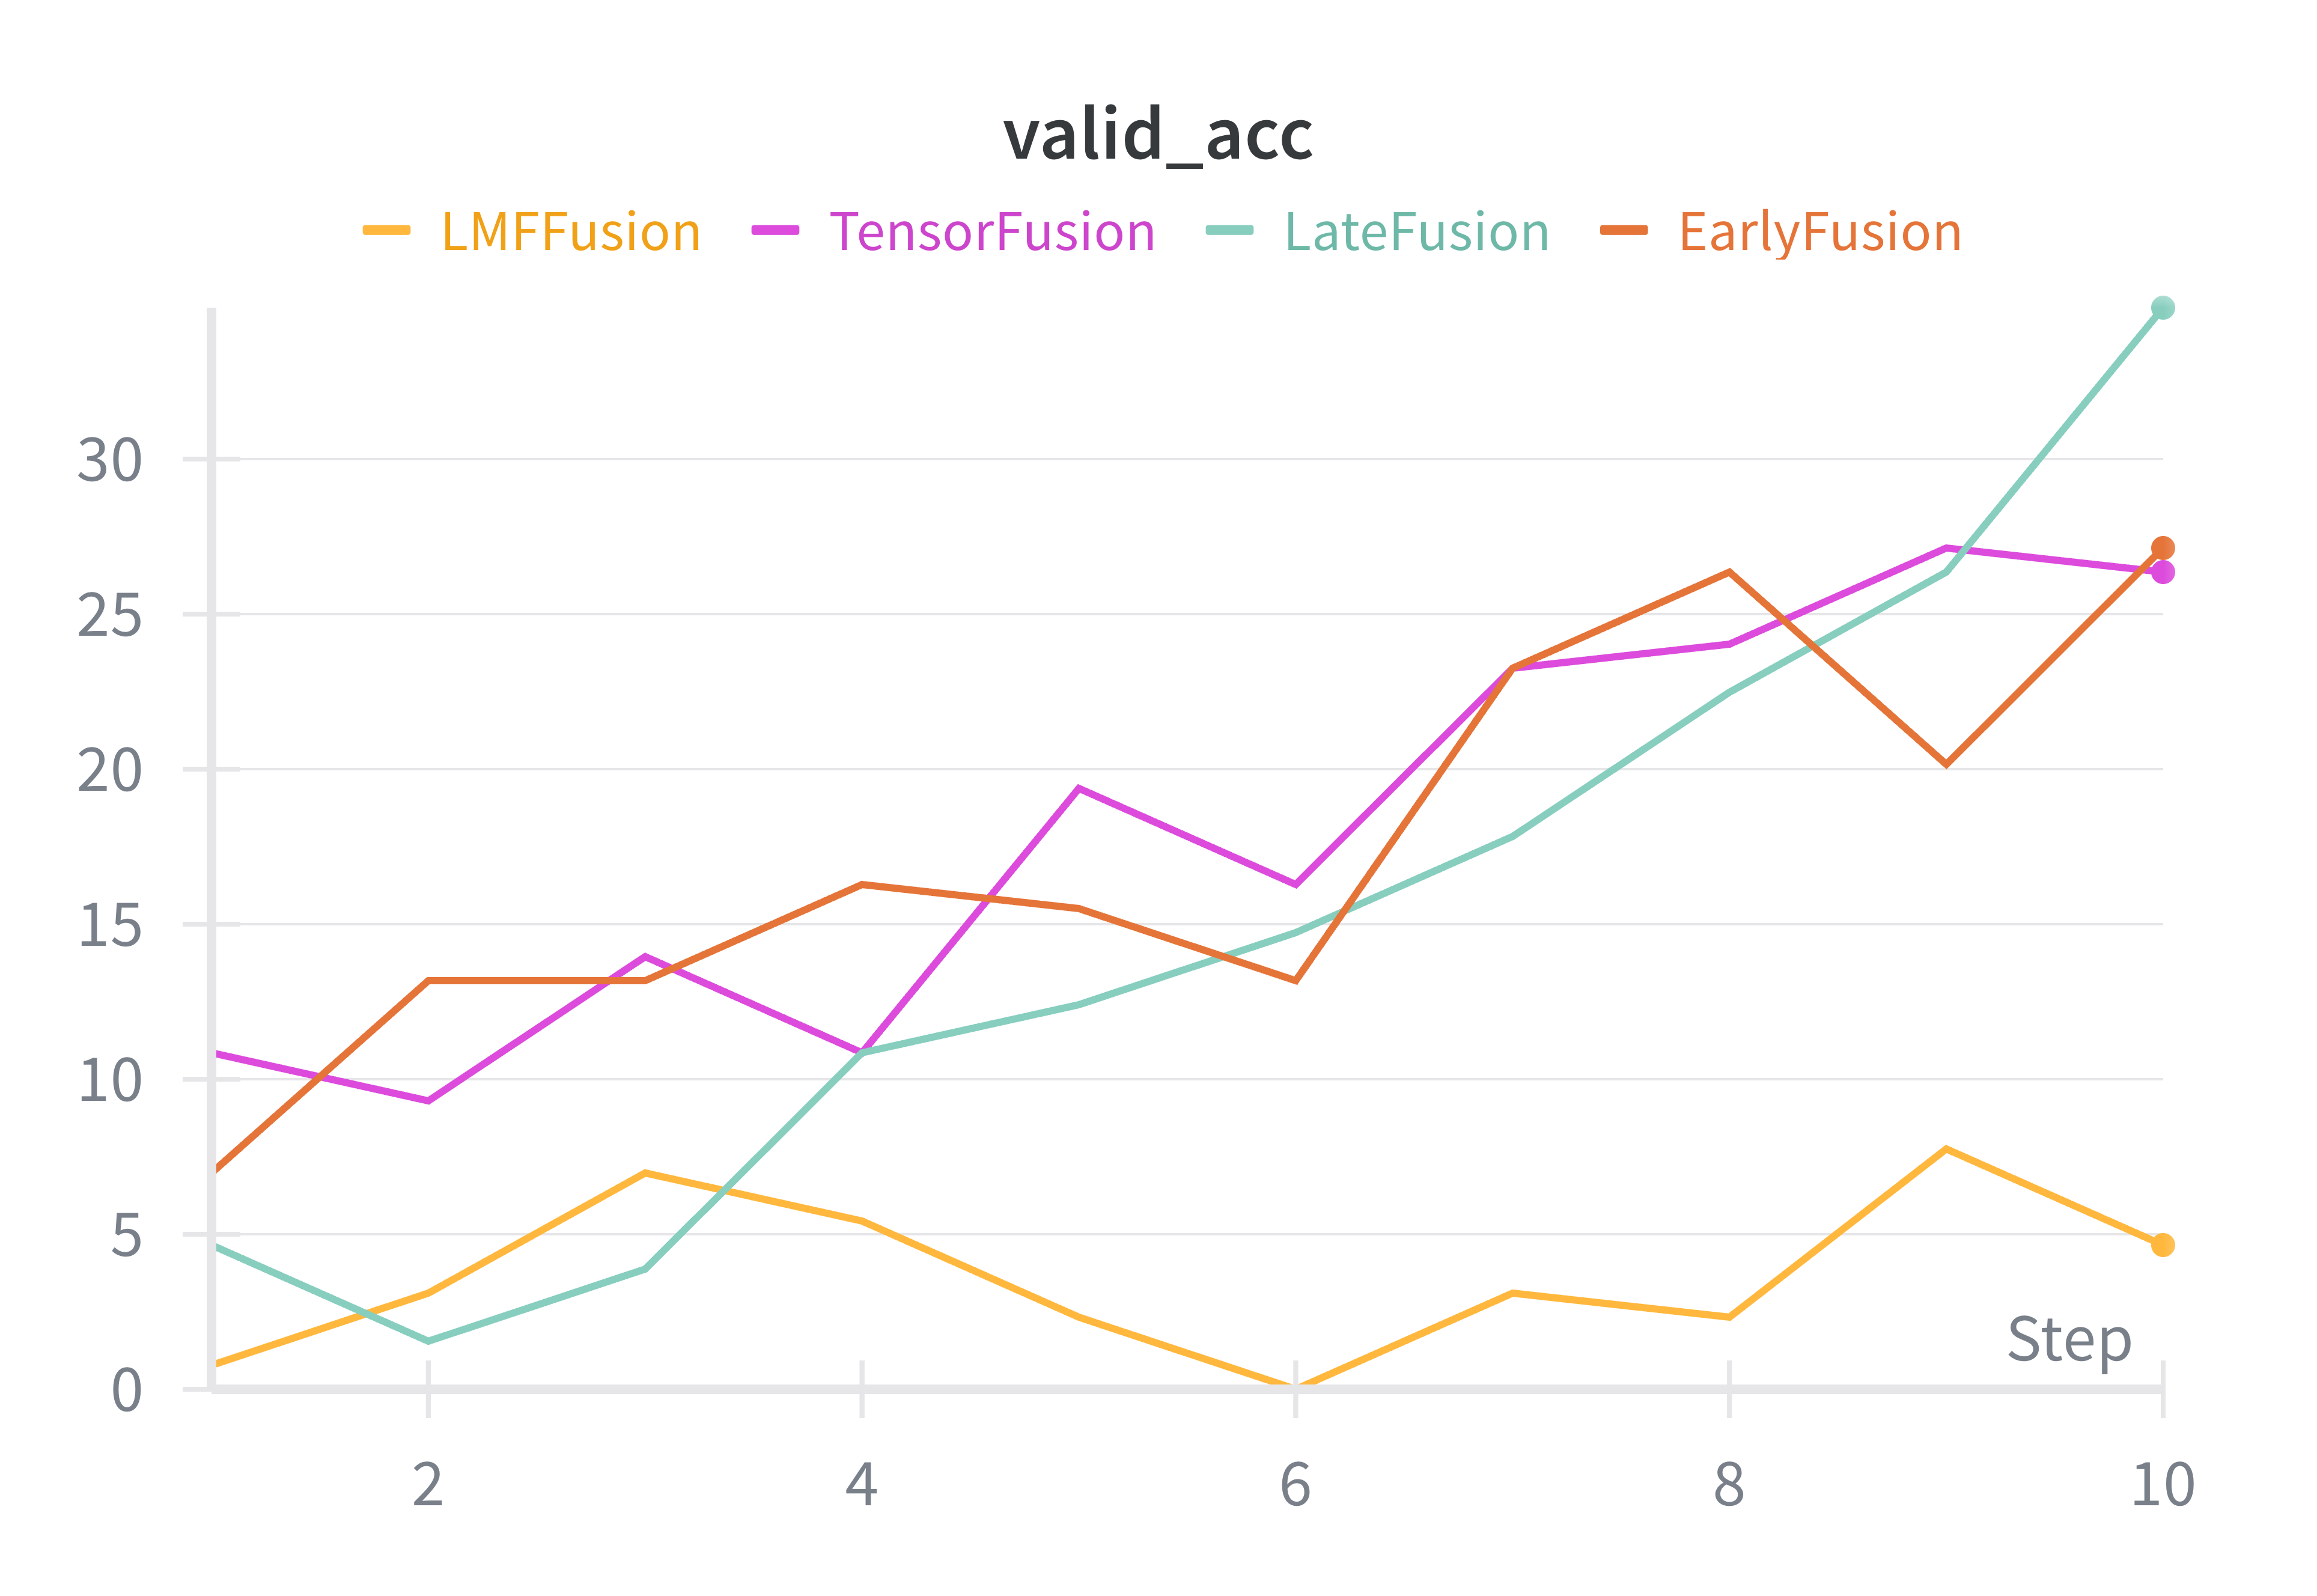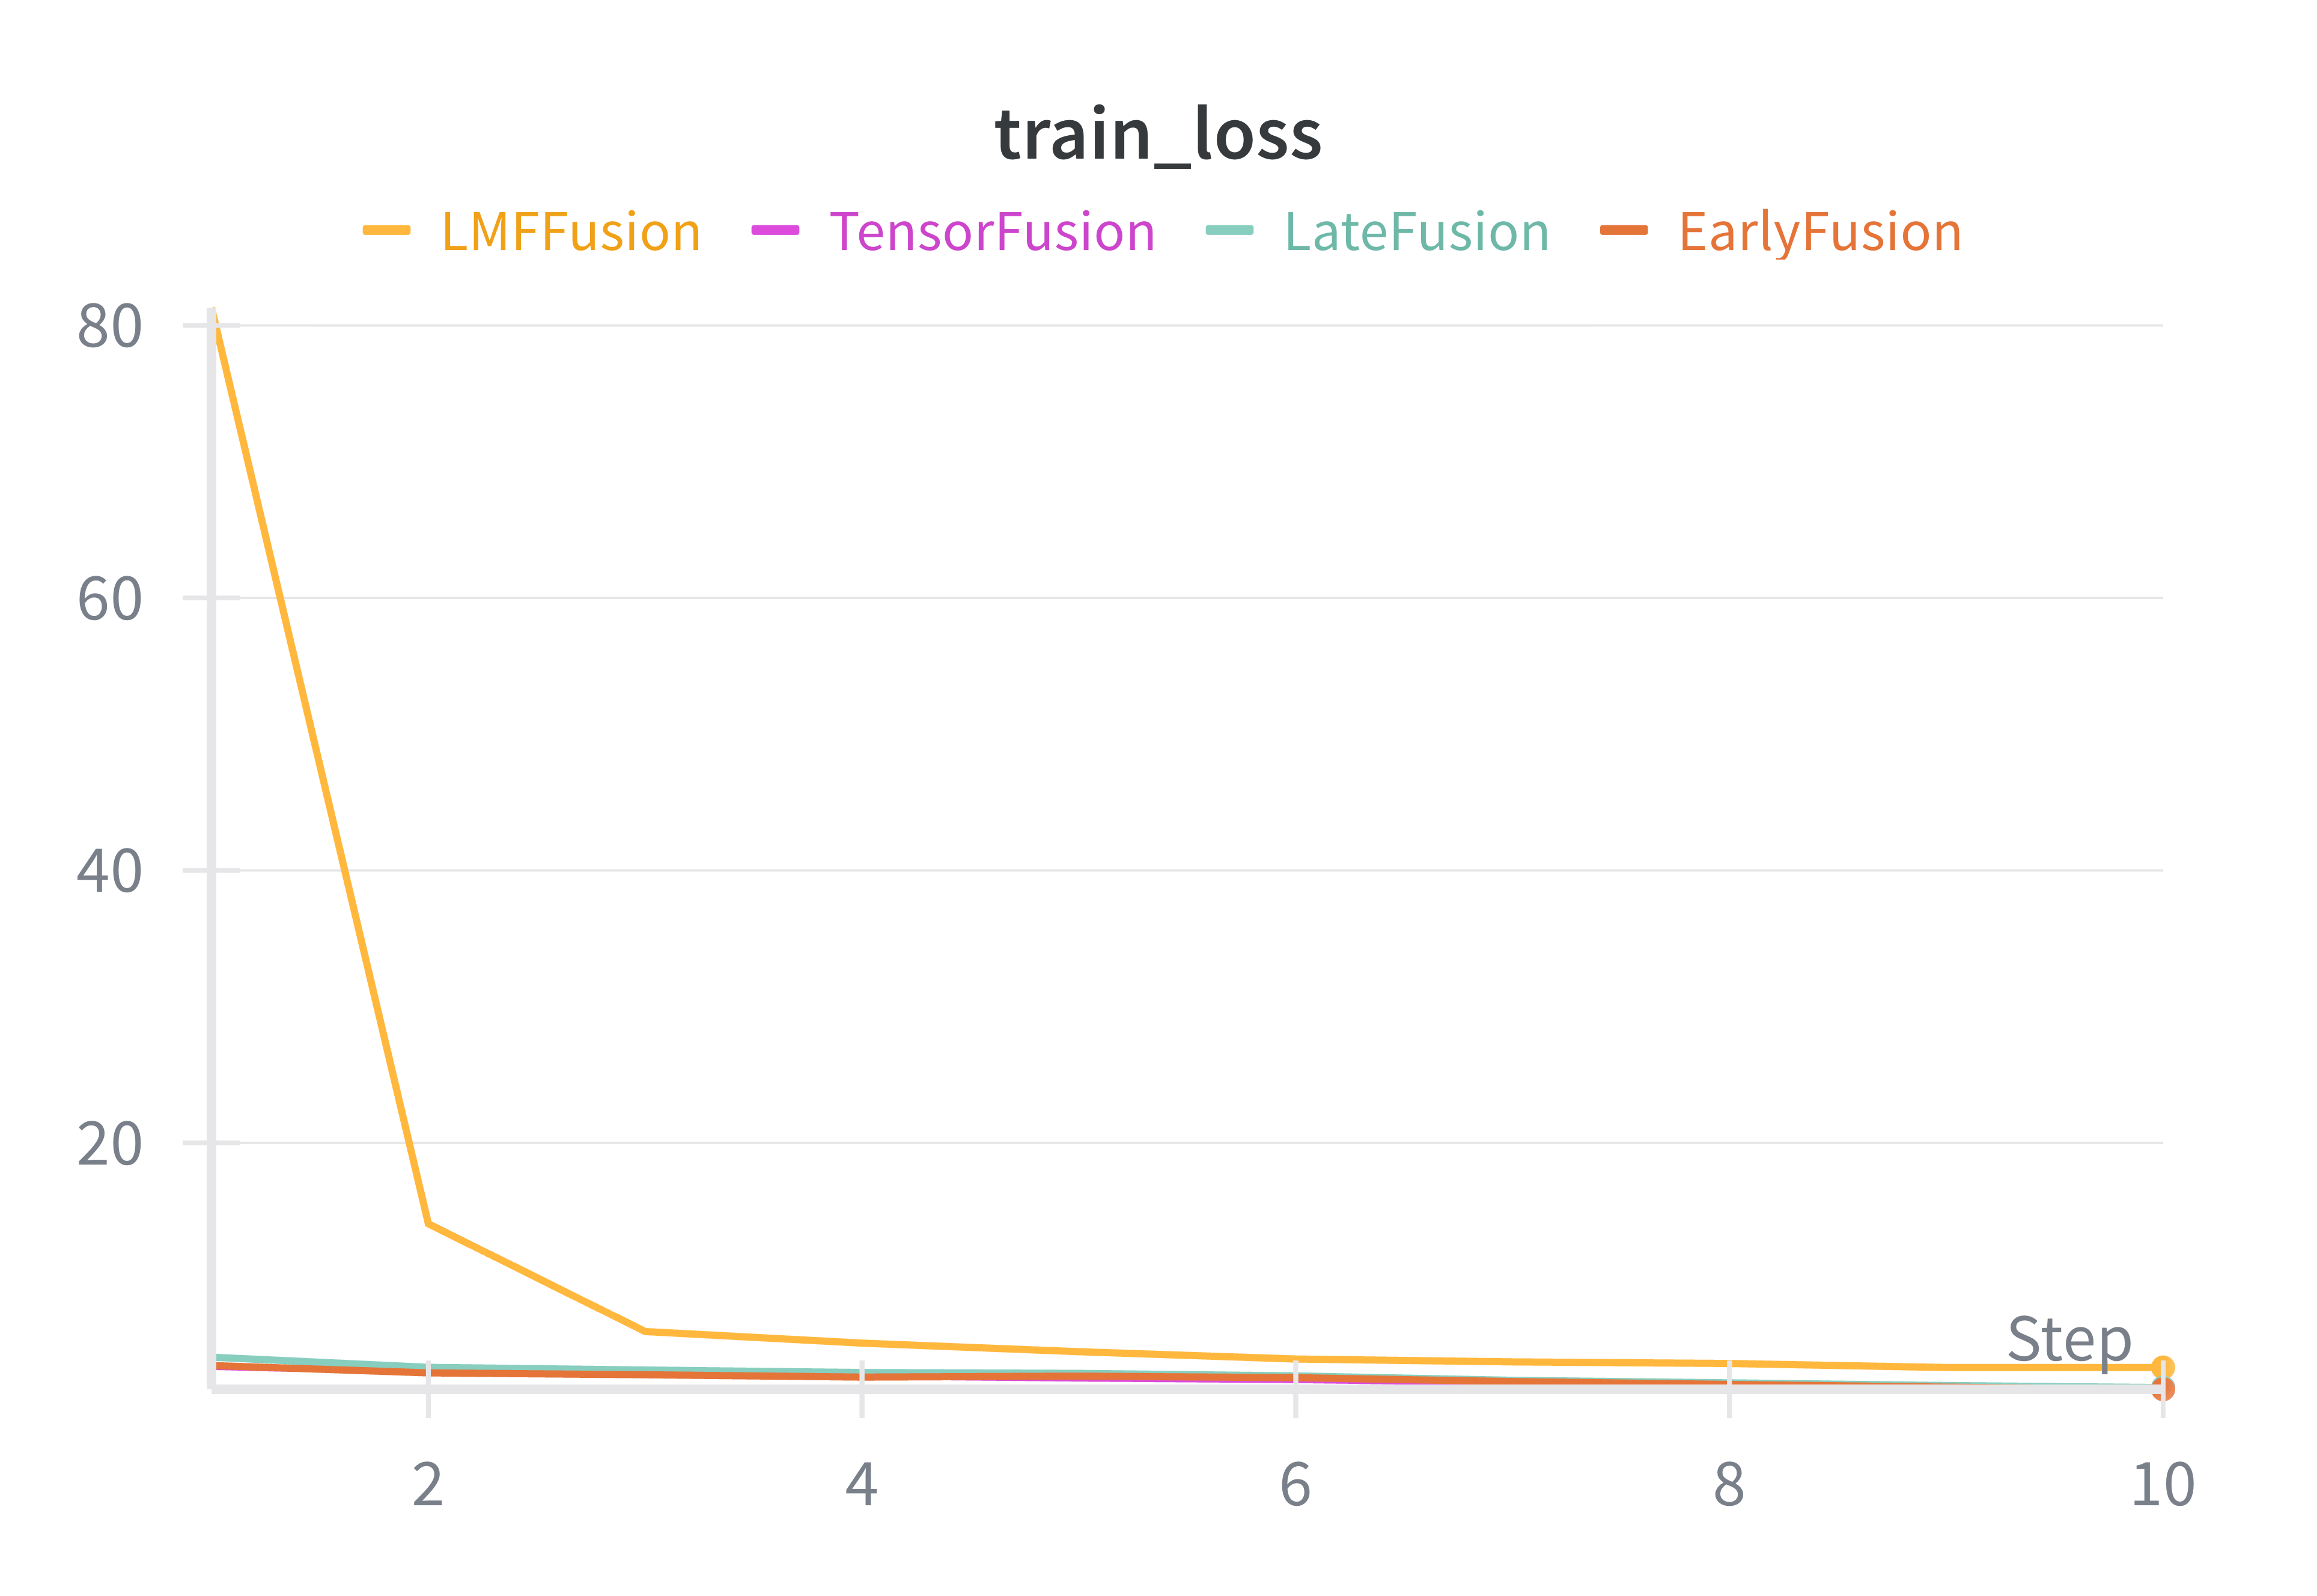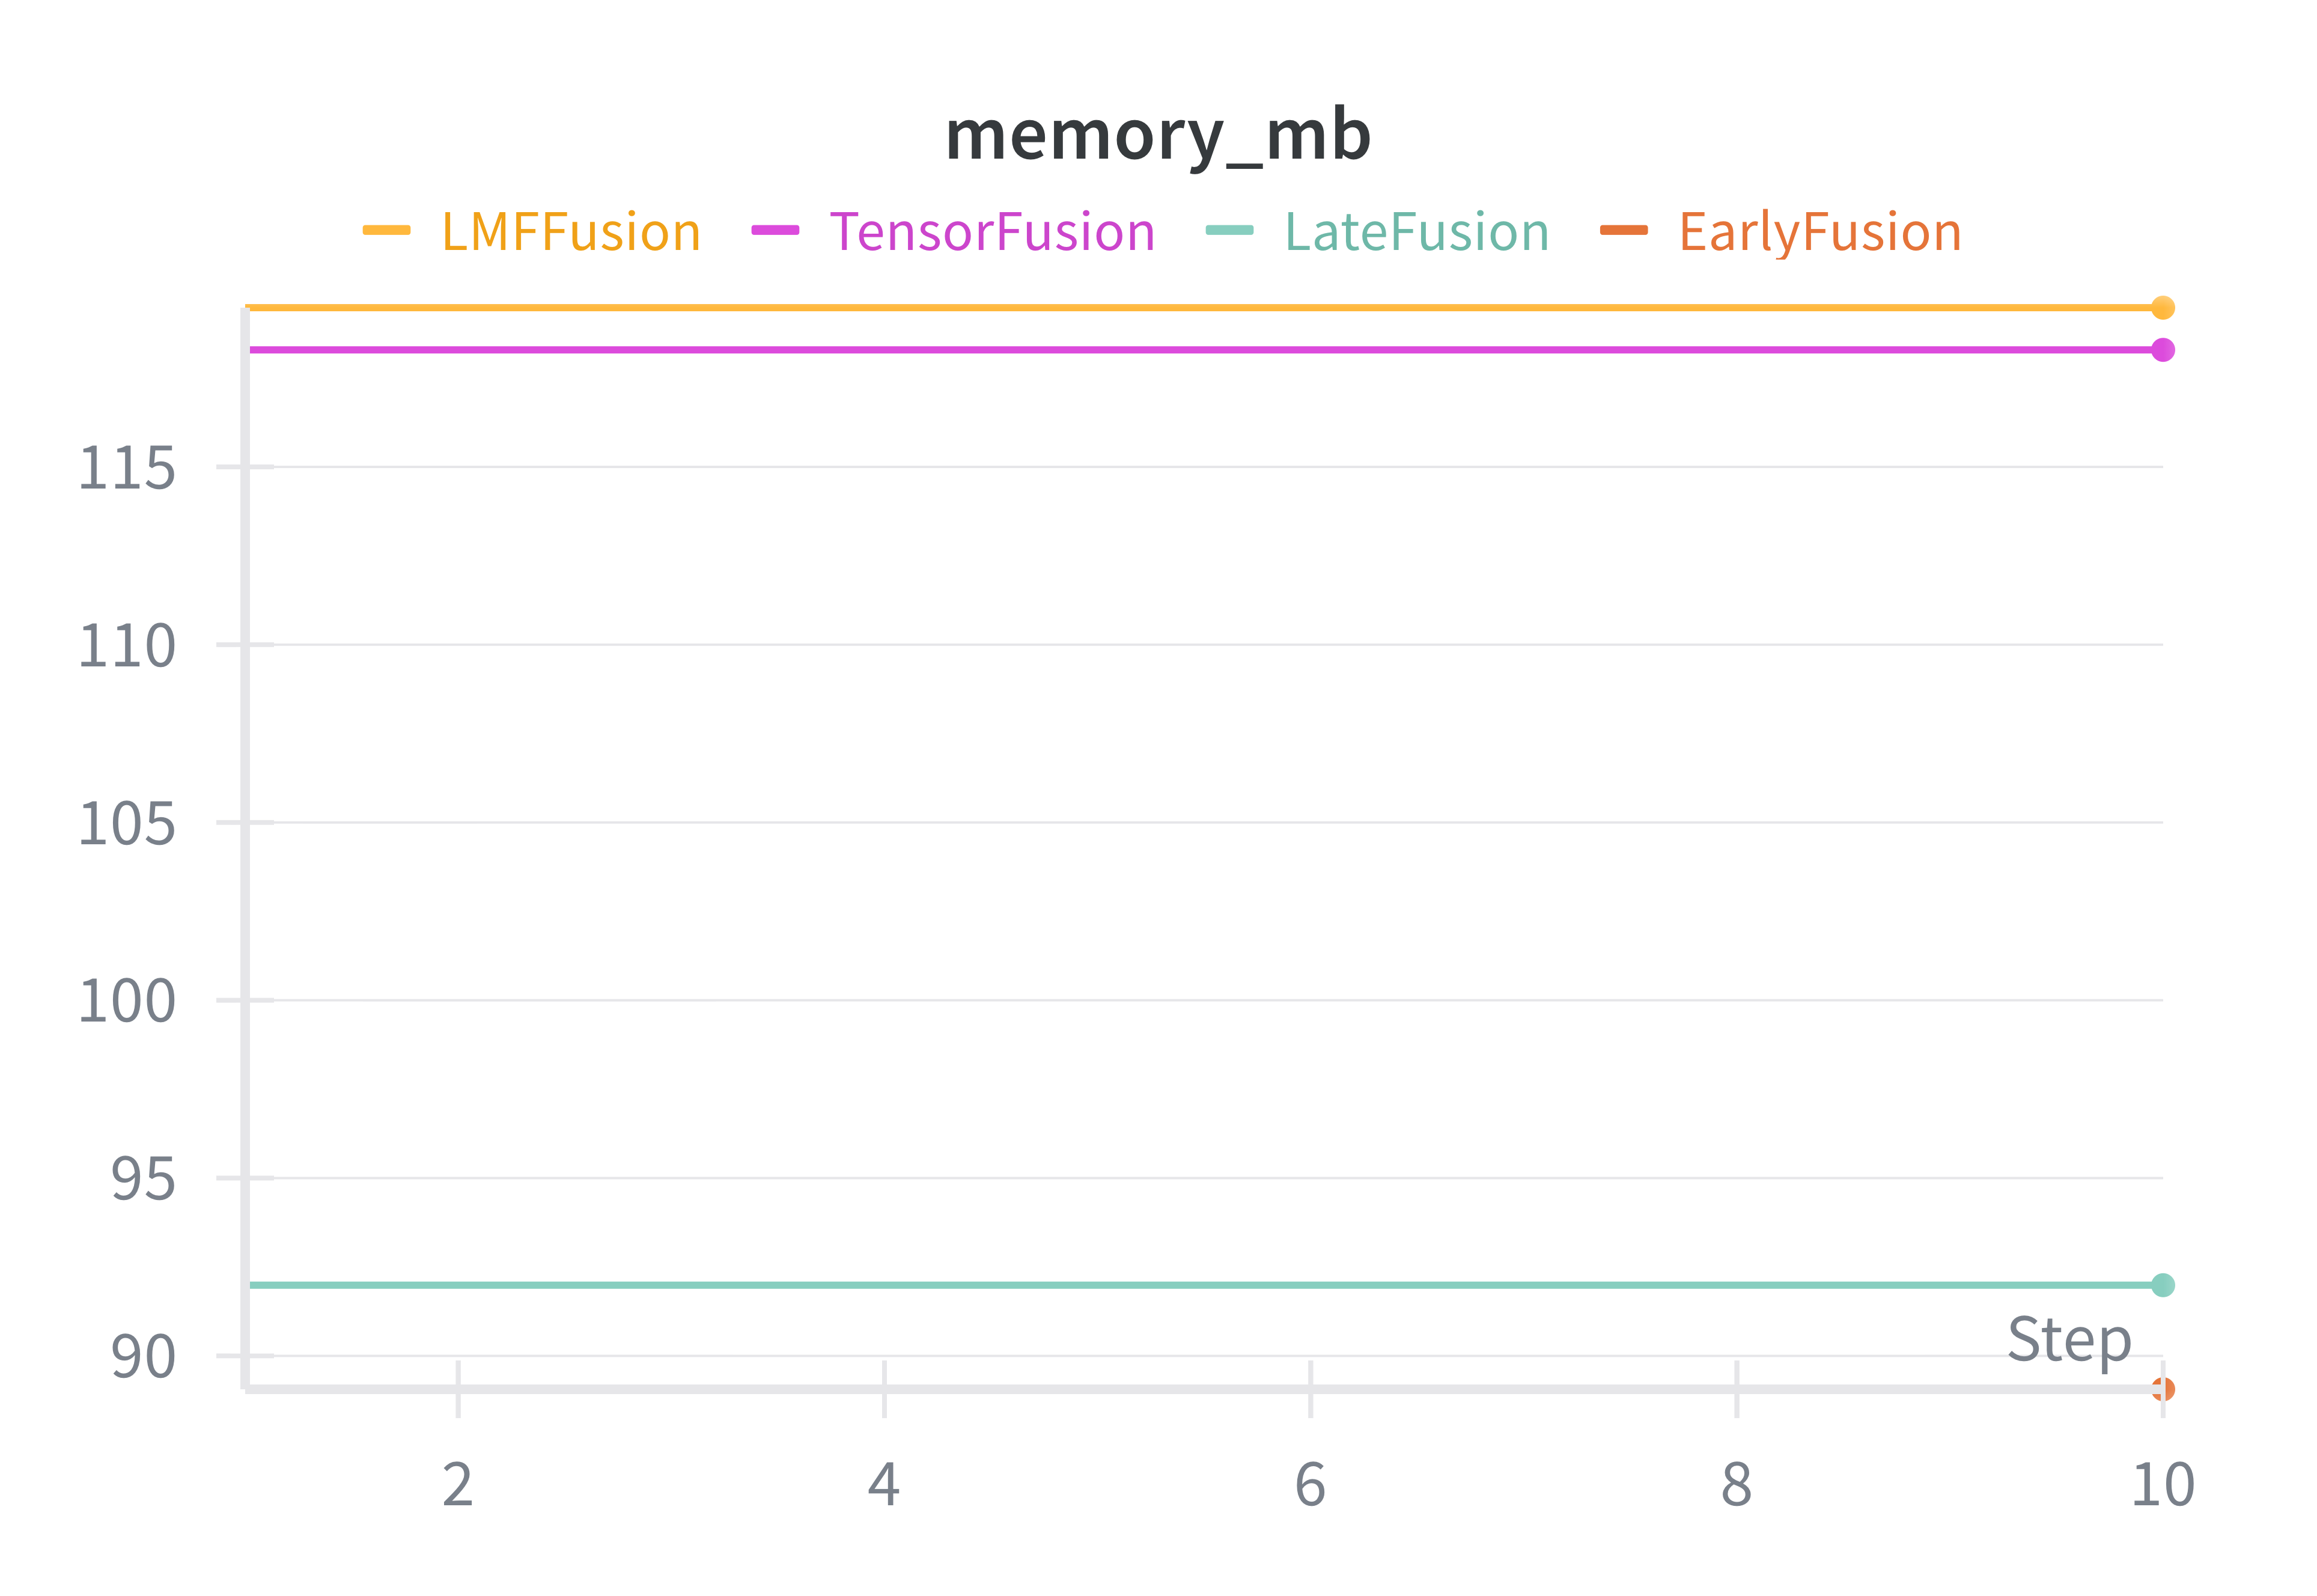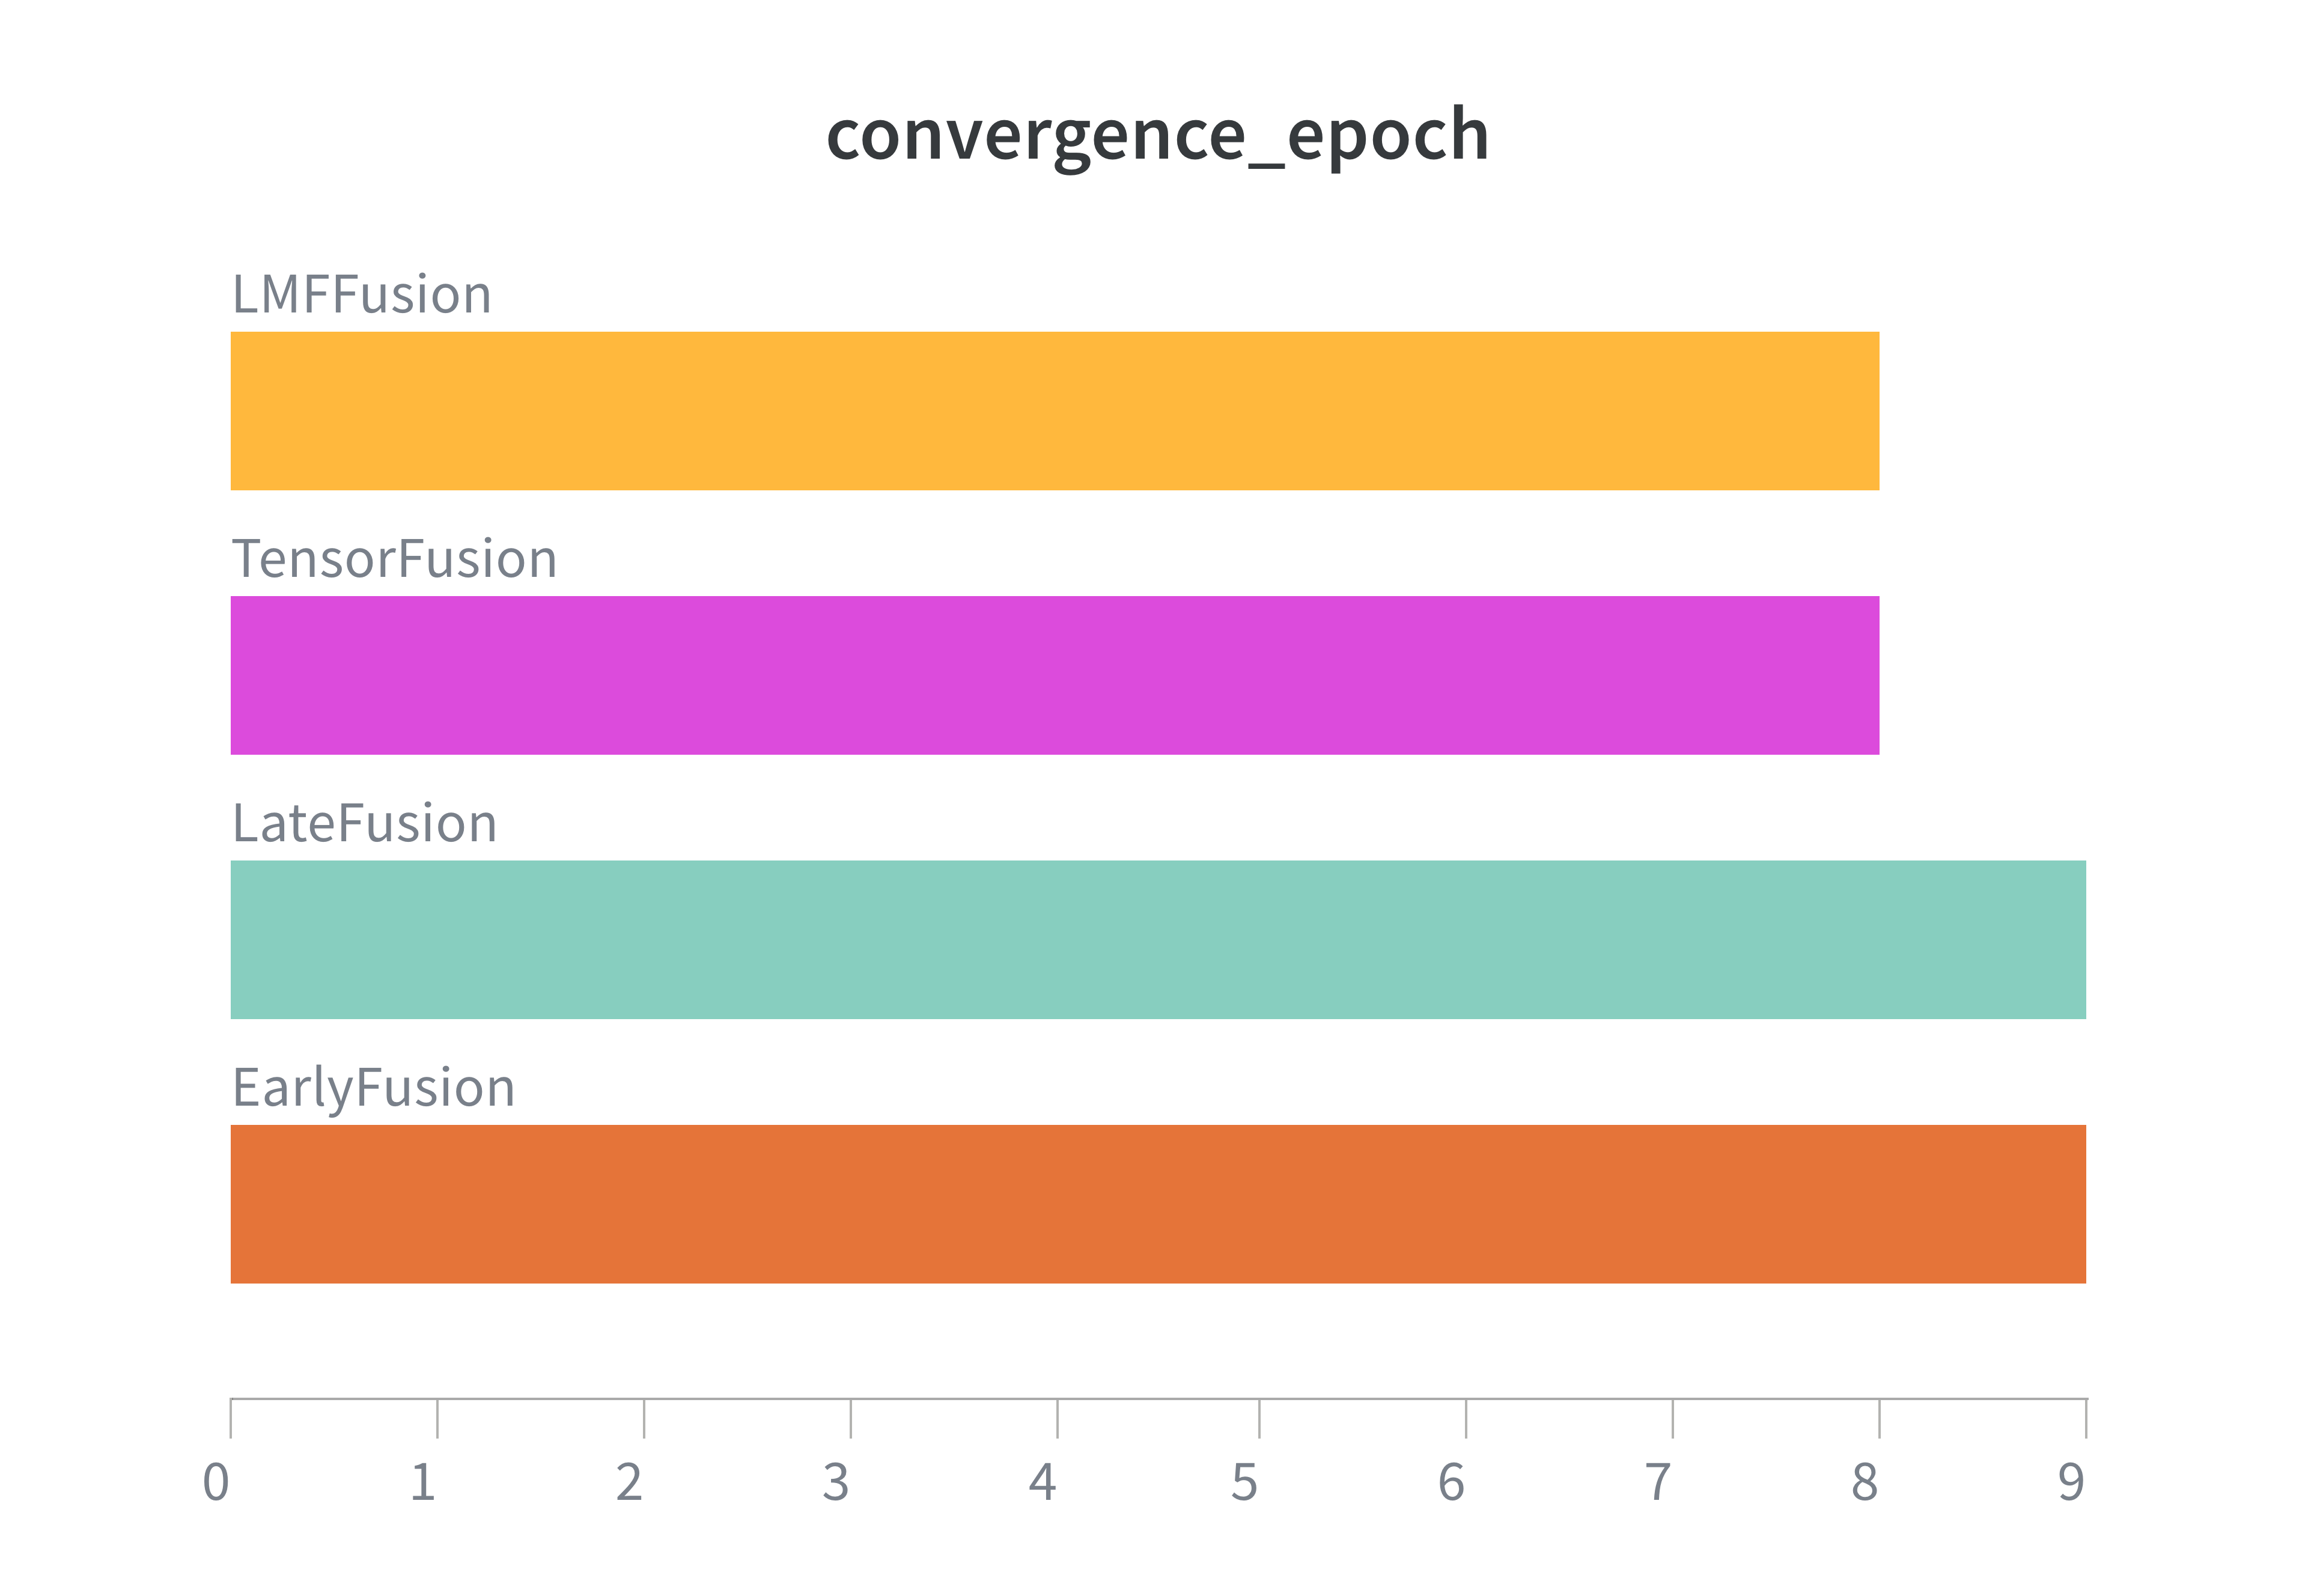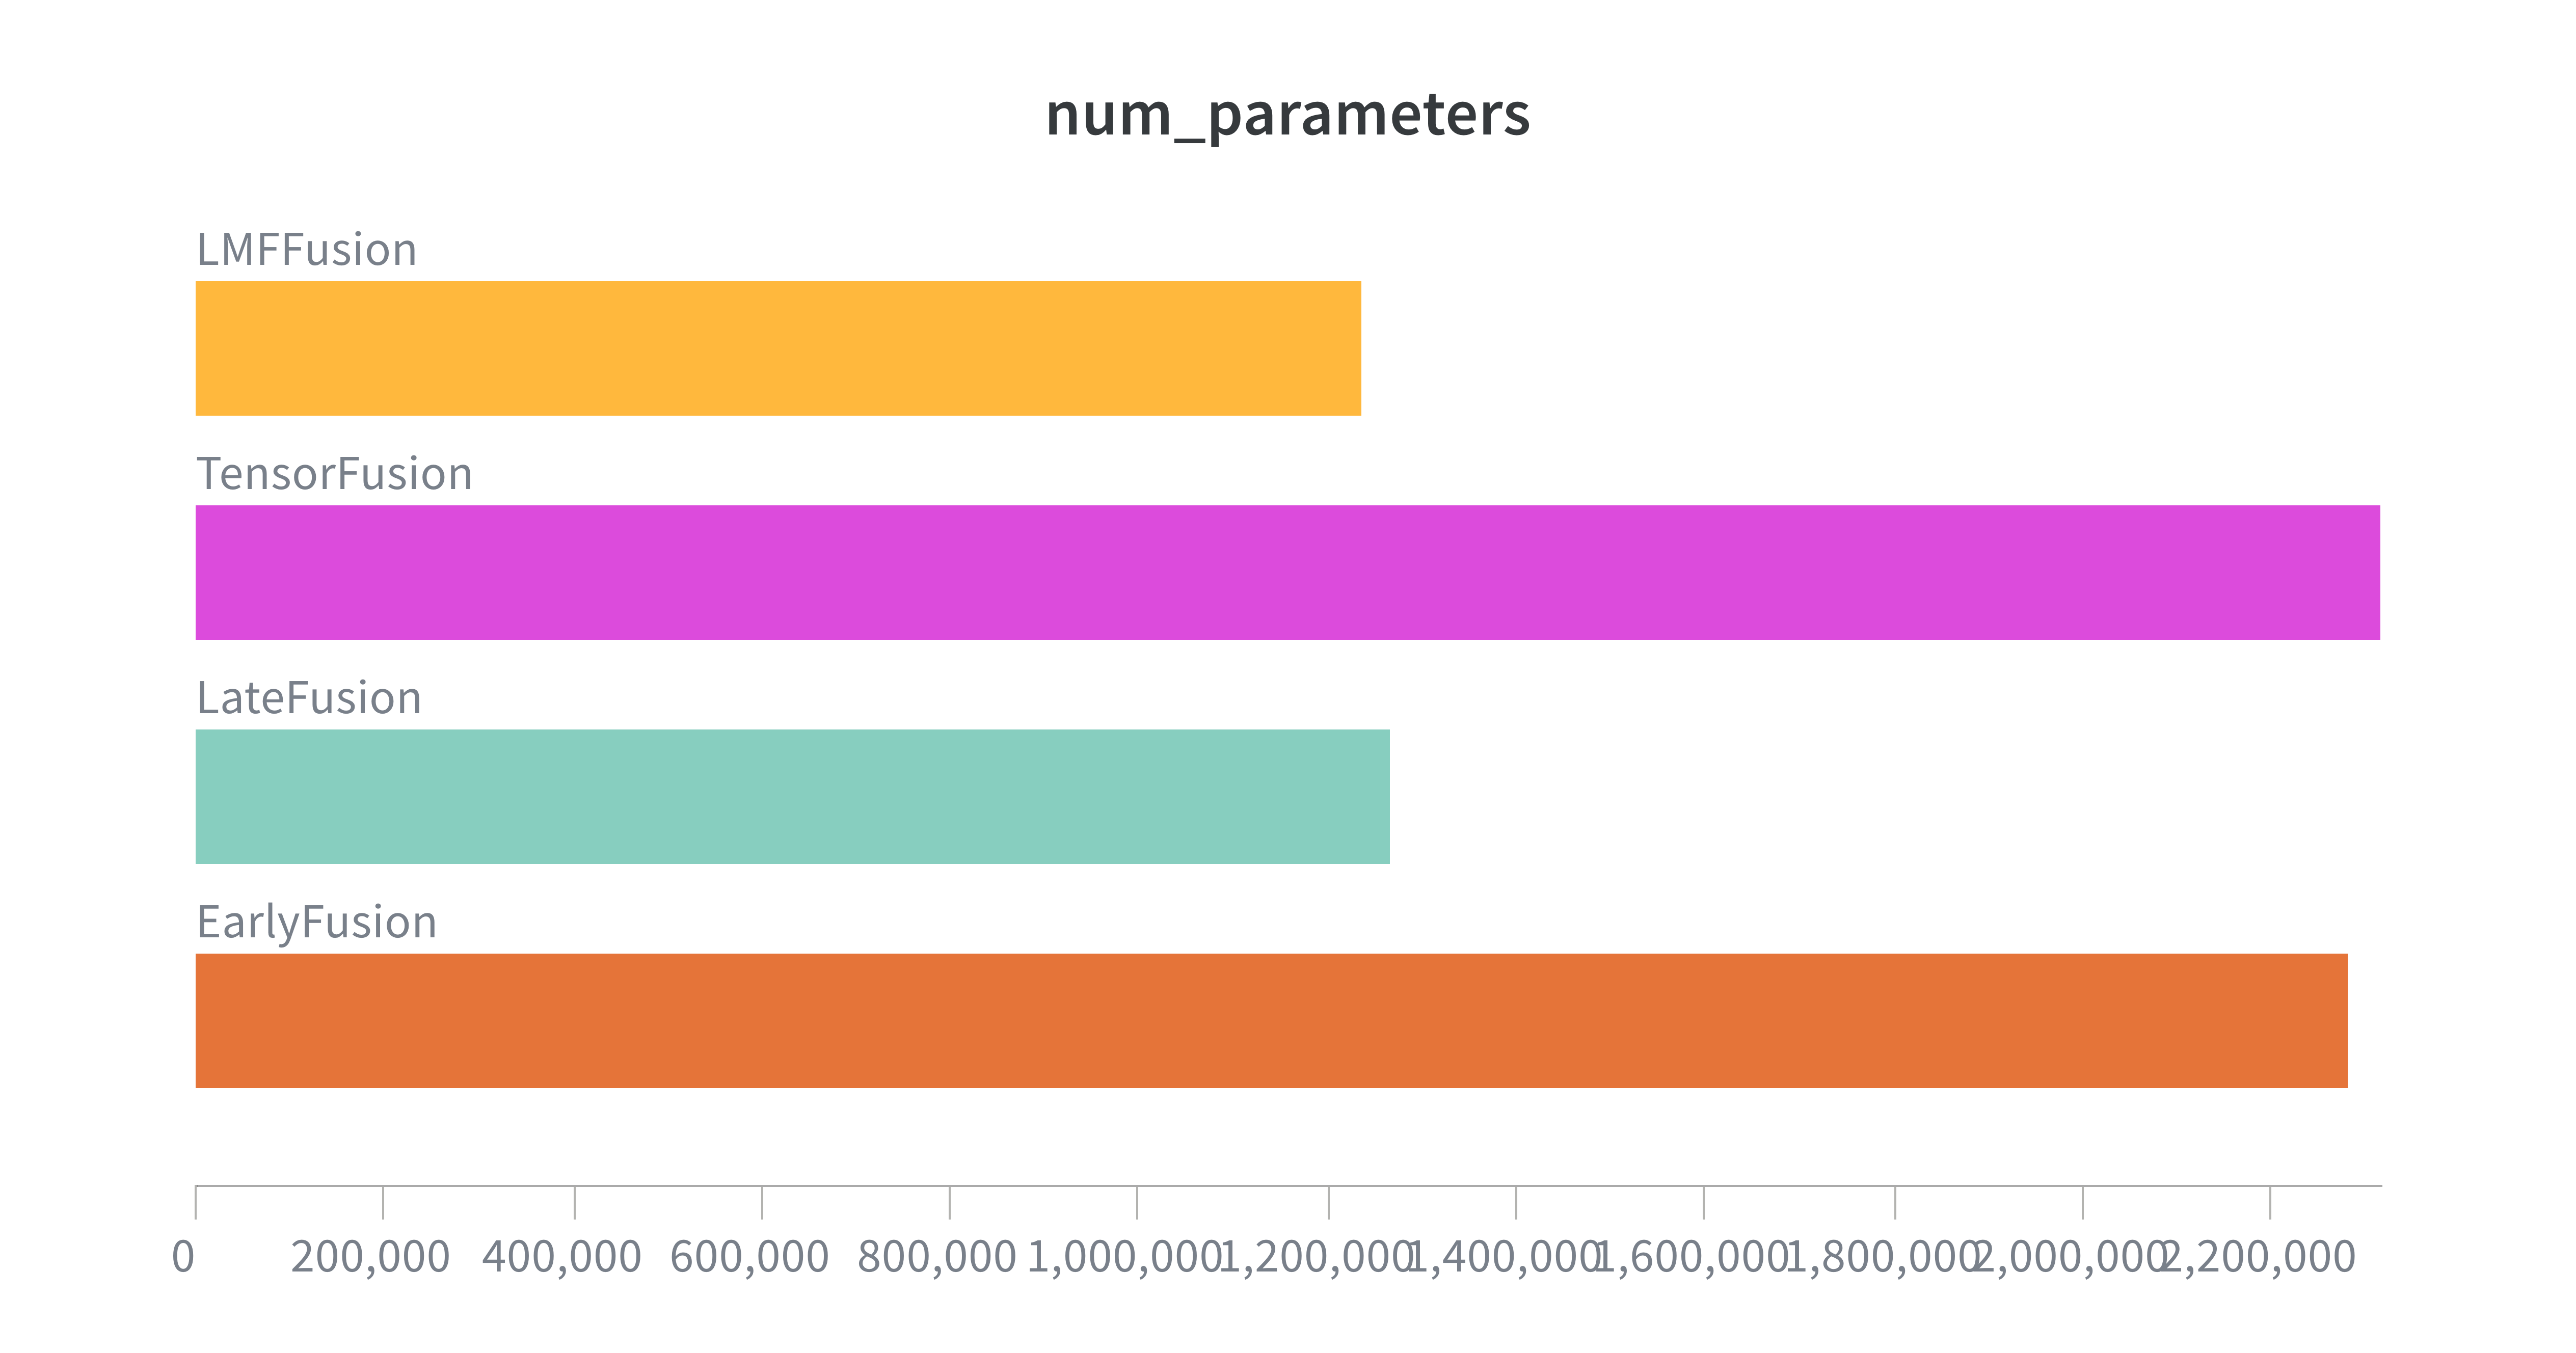

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-95pzwyzg
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-95pzwyzg
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 78.3 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=fef004fab5be1407e0e32bf8c75d95f244f5c233b10f1cf4dd1ca7beb8af066a
  Stored in directory: /tmp/pip-ephem-wheel-cache-tre1jj_q/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1


In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 63.9MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [ ]:
image_filename = "/content/smileman.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 93.90%
       a photo of a sad person: 3.59%
    a photo of an angry person: 2.50%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [ ]:
base_path = '/content/drive/MyDrive/utd_mhad'
dataset = UTDDataset(base_path, num_frames=10, img_size=64)
print(f"Total samples: {len(dataset)}")

Total samples: 861


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1=64, dim_x2=64, embedded_dim=128, temp=0.07):
    super(CLModel, self).__init__()
    # 1. Create Encoders for modalities
    self.encoder_a = VideoEncoder(output_dim=dim_x1)  # RGB Video encoder
    self.encoder_b = IMUEncoder(output_dim=dim_x2)    # IMU encoder


    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    self.projector_a = nn.Sequential(
        nn.Linear(dim_x1, 256),
        nn.ReLU(),
        nn.Linear(256, embedded_dim)
    )
    self.projector_b = nn.Sequential(
        nn.Linear(dim_x2, 256),
        nn.ReLU(),
        nn.Linear(256, embedded_dim)
    )
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)
    self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1/temp))

  def forward(self, x1, x2):
    # 1. Extract the raw features

    feat_a = self.encoder_a(x1)
    feat_b = self.encoder_b(x2)
    # 2. Project them to the embedding space

    emb_a = self.projector_a(feat_a)
    emb_b = self.projector_b(feat_b)
    # 3. Normalize vectors and return

    emb_a = F.normalize(emb_a, dim=1)
    emb_b = F.normalize(emb_b, dim=1)

    return emb_a, emb_b

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
    def __init__(self, model=None):  # model is optional
        super(ContrastiveLoss, self).__init__()
        self.model = model
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x1_emb, x2_emb, logit_scale):
        # 1. Get batch size
        batch_size = x1_emb.shape[0]

        # 2. Similarity matrix using einsum + temperature scaling
        scale = logit_scale.exp()
        sim_matrix = torch.einsum('id,jd->ij', x1_emb, x2_emb) * scale

        # 3. Labels: correct match for index i is i
        labels = torch.arange(batch_size).to(x1_emb.device)

        # 4. Symmetric loss
        loss_rows = self.loss_fn(sim_matrix, labels)
        loss_cols = self.loss_fn(sim_matrix.T, labels)
        return (loss_rows + loss_cols) / 2


# Dataloader that returns only (video, imu) without labels
class UTDPairDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        video, imu, _ = self.base[idx]  # Discard label
        return video.float(), imu.float()

# Create pair dataloaders
pair_dataset = UTDPairDataset(dataset)
total = len(pair_dataset)
train_size = int(0.7 * total)
valid_size = int(0.15 * total)
test_size = total - train_size - valid_size

train_pair, valid_pair, test_pair = torch.utils.data.random_split(
    pair_dataset, [train_size, valid_size, test_size]
)

pair_trainloader = torch.utils.data.DataLoader(train_pair, batch_size=16, shuffle=True)
pair_testloader  = torch.utils.data.DataLoader(test_pair,  batch_size=16, shuffle=False)

# Run training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cl_model = CLModel(dim_x1=64, dim_x2=64, embedded_dim=128, temp=0.07)
contrastive_loss = ContrastiveLoss()

train_cl(cl_model, contrastive_loss, pair_trainloader,
            num_epochs=10, learning_rate=3e-4, device=device)



Starting training for 10 epochs...
Epoch [1/10] | Loss: 2.8082
Epoch [2/10] | Loss: 2.7476
Epoch [3/10] | Loss: 2.6798
Epoch [4/10] | Loss: 2.5567
Epoch [5/10] | Loss: 2.4720
Epoch [6/10] | Loss: 2.2673
Epoch [7/10] | Loss: 2.1750
Epoch [8/10] | Loss: 2.1045
Epoch [9/10] | Loss: 1.9820
Epoch [10/10] | Loss: 1.8753


In [ ]:
import torch.optim as optim
# Training function
def train_cl(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.logit_scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [ ]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores



# Get a test batch
video_batch, imu_batch = next(iter(pair_testloader))

# Query: first video sample
query_video = video_batch[0].float()  # (10, 1, 64, 64)

# Candidates: all IMU samples in batch
candidate_imu = imu_batch.float()     # (batch, 160, 6)

# Predict best match
best_idx, scores = predict_best_match(
    cl_model, query_video, candidate_imu, device
)

print(f"Query video index: 0")
print(f"Best matching IMU index: {best_idx}")

# Try multiple queries to see zero-shot performance
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
video_batch, imu_batch = next(iter(pair_testloader))

correct = 0
total = len(video_batch)

for i in range(total):
    query_video = video_batch[i].float()
    candidate_imu = imu_batch.float()

    best_idx, scores = predict_best_match(
        cl_model, query_video, candidate_imu, device
    )

    if best_idx == i:
        correct += 1

print(f"\nZero-shot accuracy: {correct}/{total} = {100*correct/total:.1f}%")

Best match: 0 with score 0.38202470541000366
Query video index: 0
Best matching IMU index: 0
Best match: 0 with score 0.38202470541000366
Best match: 1 with score 0.4100171625614166
Best match: 7 with score 0.3492647409439087
Best match: 3 with score 0.46637362241744995
Best match: 15 with score 0.3698560297489166
Best match: 1 with score 0.3754969835281372
Best match: 3 with score 0.43765565752983093
Best match: 1 with score 0.4258711338043213
Best match: 1 with score 0.41505011916160583
Best match: 15 with score 0.4561713933944702
Best match: 11 with score 0.5548669099807739
Best match: 11 with score 0.6273301243782043
Best match: 15 with score 0.3597634732723236
Best match: 11 with score 0.41577693819999695
Best match: 10 with score 0.37729597091674805
Best match: 15 with score 0.4624176025390625

Zero-shot accuracy: 5/16 = 31.2%


Best match: 0 with score 0.38202470541000366
Best match: 1 with score 0.4100171625614166
Best match: 7 with score 0.3492647409439087
Best match: 3 with score 0.46637362241744995
Best match: 15 with score 0.3698560297489166
Best match: 1 with score 0.3754969835281372
Best match: 3 with score 0.43765565752983093
Best match: 1 with score 0.4258711338043213
Best match: 1 with score 0.41505011916160583
Best match: 15 with score 0.4561713933944702
Best match: 11 with score 0.5548669099807739
Best match: 11 with score 0.6273301243782043
Best match: 15 with score 0.3597634732723236
Best match: 11 with score 0.41577693819999695
Best match: 10 with score 0.37729597091674805
Best match: 15 with score 0.4624176025390625


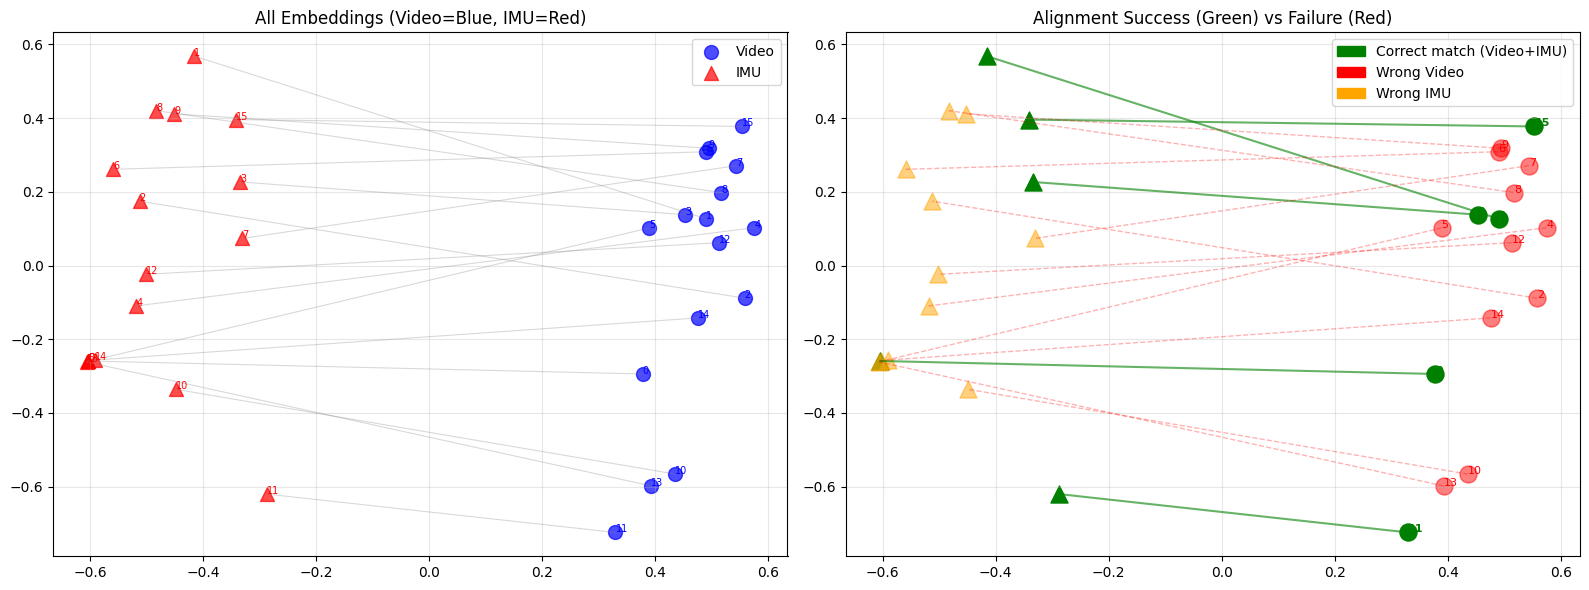

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
video_batch, imu_batch = next(iter(pair_testloader))

# Get all embeddings
cl_model.eval()
with torch.no_grad():
    feat_a = cl_model.encoder_a(video_batch.float().to(device))
    emb_a = F.normalize(cl_model.projector_a(feat_a), dim=1).cpu().numpy()

    feat_b = cl_model.encoder_b(imu_batch.float().to(device))
    emb_b = F.normalize(cl_model.projector_b(feat_b), dim=1).cpu().numpy()

# Reduce to 2D with PCA for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
all_emb = np.concatenate([emb_a, emb_b], axis=0)
all_2d = pca.fit_transform(all_emb)

video_2d = all_2d[:len(emb_a)]
imu_2d = all_2d[len(emb_a):]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: All embeddings ---
ax = axes[0]
ax.scatter(video_2d[:, 0], video_2d[:, 1], c='blue', marker='o',
           s=100, label='Video', alpha=0.7)
ax.scatter(imu_2d[:, 0], imu_2d[:, 1], c='red', marker='^',
           s=100, label='IMU', alpha=0.7)

# Draw lines between matched pairs
for i in range(len(video_2d)):
    ax.plot([video_2d[i,0], imu_2d[i,0]],
            [video_2d[i,1], imu_2d[i,1]],
            'gray', alpha=0.3, linewidth=0.8)
    ax.annotate(str(i), video_2d[i], fontsize=7, color='blue')
    ax.annotate(str(i), imu_2d[i], fontsize=7, color='red')

ax.set_title('All Embeddings (Video=Blue, IMU=Red)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Highlight success vs failure ---
ax2 = axes[1]

# Get predictions
correct_idx = []
wrong_idx = []

for i in range(len(video_batch)):
    query_video = video_batch[i].float()
    candidate_imu = imu_batch.float()
    best_idx, _ = predict_best_match(cl_model, query_video, candidate_imu, device)
    if best_idx == i:
        correct_idx.append(i)
    else:
        wrong_idx.append(i)

# Plot correct matches in green, wrong in red
for i in correct_idx:
    ax2.scatter(video_2d[i,0], video_2d[i,1], c='green', marker='o', s=150)
    ax2.scatter(imu_2d[i,0], imu_2d[i,1], c='green', marker='^', s=150)
    ax2.plot([video_2d[i,0], imu_2d[i,0]],
             [video_2d[i,1], imu_2d[i,1]],
             'green', alpha=0.6, linewidth=1.5)
    ax2.annotate(str(i), video_2d[i], fontsize=8, color='green', fontweight='bold')

for i in wrong_idx:
    ax2.scatter(video_2d[i,0], video_2d[i,1], c='red', marker='o', s=150, alpha=0.5)
    ax2.scatter(imu_2d[i,0], imu_2d[i,1], c='orange', marker='^', s=150, alpha=0.5)
    ax2.plot([video_2d[i,0], imu_2d[i,0]],
             [video_2d[i,1], imu_2d[i,1]],
             'red', alpha=0.3, linewidth=1, linestyle='--')
    ax2.annotate(str(i), video_2d[i], fontsize=8, color='red')

green_patch = mpatches.Patch(color='green', label='Correct match (Video+IMU)')
red_patch = mpatches.Patch(color='red', label='Wrong Video')
orange_patch = mpatches.Patch(color='orange', label='Wrong IMU')
ax2.legend(handles=[green_patch, red_patch, orange_patch])
ax2.set_title('Alignment Success (Green) vs Failure (Red)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('contrastive_alignment.png', dpi=150)
plt.show()

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?

    One surprising result was that the contrastive learning model achieved 31.2% zero-shot accuracy without ever seeing explicit class labels during training. This is significantly above the random baseline of 3.7% for 27 classes, which suggests that the model successfully learned meaningful cross-modal alignment purely from the co-occurrence of video and IMU data. Another surprising finding was that some IMU samples were matched by multiple video queries (e.g., index 1, 11, and 15 appeared frequently as best matches), suggesting the model found certain IMU patterns to be more "universal" anchors in the embedding space.


2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?

    Cross-entropy loss is used in contrastive learning because it naturally frames the problem as a classification task. Given a query embedding, the model must identify which of the N candidates in the batch is the correct match — this is exactly an N-way classification problem. The similarity matrix produces a score for each candidate, and cross-entropy loss penalizes the model when the correct match does not have the highest score. Additionally, the symmetric formulation (loss in both directions: video→IMU and IMU→video) ensures both modalities are pulled toward each other equally, which leads to a more balanced and well-aligned embedding space.


3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

    The PCA visualization above shows that Video embeddings (blue) and IMU embeddings (red) occupy two separated regions of the embedding space, indicating the two modalities have not fully aligned.

    successful alignments (green): Correctly matched pairs like indices 0, 3, 11, 15 tend to have shorter connecting lines, meaning their embeddings landed closer together. These are likely actions with distinctive and consistent motion patterns that both modalities capture well.

    failed alignments (red dashed): Most failures show long crossing lines between the two modality clusters. Many IMU embeddings cluster tightly together, suggesting the IMU encoder struggled to distinguish similar actions. This likely happens for actions that feel similar to the sensor but look different visually.

    the main reason for failures is the modality gap — the two encoders learned somewhat independent representations. With only 861 samples, more training data and longer training would likely improve alignment.

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?

    I think the code practice part for different modal fusion is most useful and interesting, because it provides us the direct way to implement what we've learned from lecture. And to compare each method with our own dataset.

2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.

    Several concepts from this assignment are directly relevant to PG-MoE. Late fusion provides the foundation for our modality-specific encoders, while contrastive learning could be used to pre-train better cross-modal representations between RGB and IMU before applying the phase-gated switching mechanism.

3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

    I hope we can have more coding practice or more detailed tutorails.